In [93]:
import os
import sys
sys.path.insert(0,os.path.abspath('../src/'))

In [94]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, mom6_latlon2ij


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
path_old = '/glade/work/bryan/MOM6-data-files/Topography/tx2_3v2/'
file_old = 'topo.sub150.tx2_3v2.srtm.edit4.SmL1.0_C1.0.nc'
df_old = xr.open_dataset(path_old+file_old)
df_old

<xarray.Dataset> Size: 20MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/15)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D2_mean     (lath, lonh) float32 1MB ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20221228
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v2
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 04/04/2023

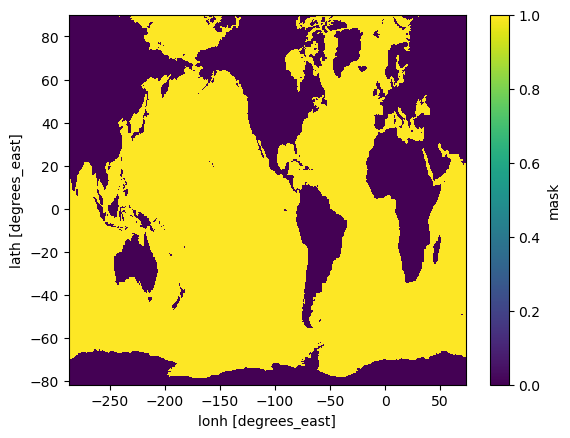

In [96]:
df_old['mask'].plot()

In [97]:
path_new = '/glade/work/bryan/MOM6-data-files/Topography/tx2_3v3_Feb2026/'
file_new = 'topo.sub150.tx2_3v3.SRTM15_V2.4.edit1.SmL1.0_C1.0.nc'
df_new = xr.open_dataset(path_new+file_new)

In [98]:
df_new

<xarray.Dataset> Size: 20MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/15)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D2_mean     (lath, lonh) float32 1MB ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260226
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/27/2026

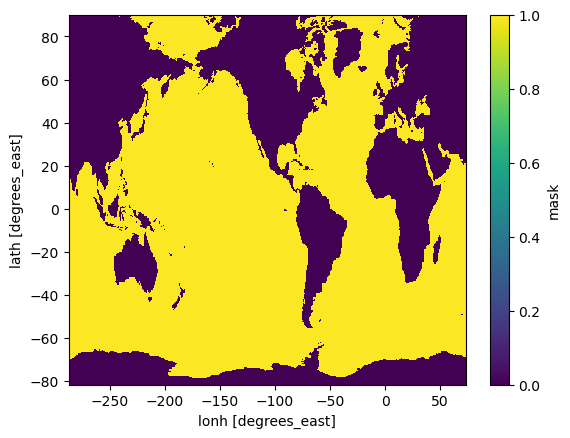

In [99]:
df_new['mask'].plot()

In [100]:
np.max(np.abs((df_old['geolat'].values - df_new['geolat'].values)))

np.float64(0.0)

In [101]:
np.max(np.abs((df_old['geolon'].values - df_new['geolon'].values)))

np.float64(0.0)

In [102]:
diff = df_old['mask'] - df_new['mask']
x = diff.where(diff != 0,drop=True).stack(grid=('lath','lonh'))
print('# of mask values changed = ',x.count().values,' min change=',x.min().values,' max change=',x.max().values)

# of mask values changed =  30  min change= 1.0  max change= 1.0


In [103]:
diff = df_old['D_interp'] - df_new['D_interp']
x = diff.where(np.abs(diff) > 0.01,drop=True).stack(grid=('lath','lonh'))
print('# of depths changed by > 1 cm = ',x.count().values,' min change=',x.min().values,' max change=',x.max().values)

# of depths changed by > 1 cm =  30  min change= 10.16926097869873  max change= 888.458740234375


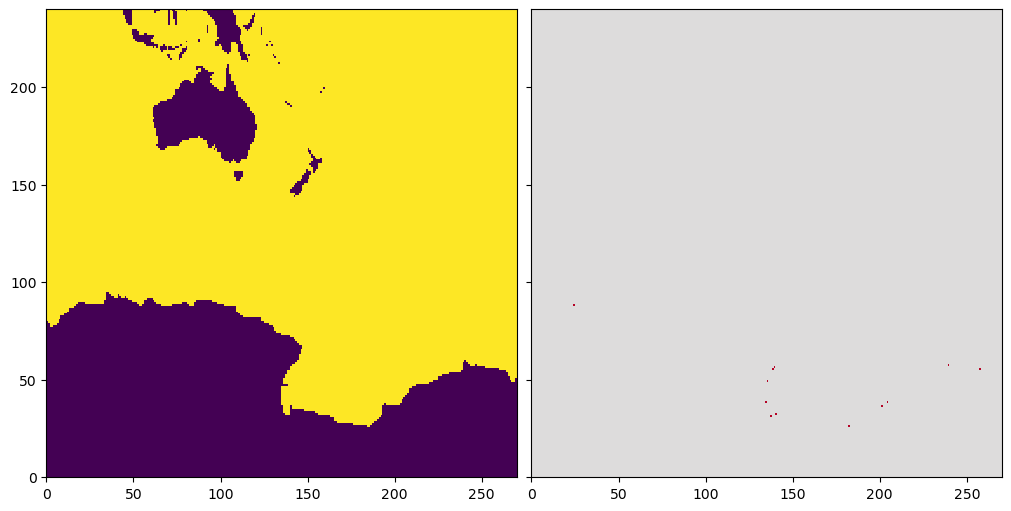

In [104]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(0,270)
ax[0].set_ylim(0,240)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

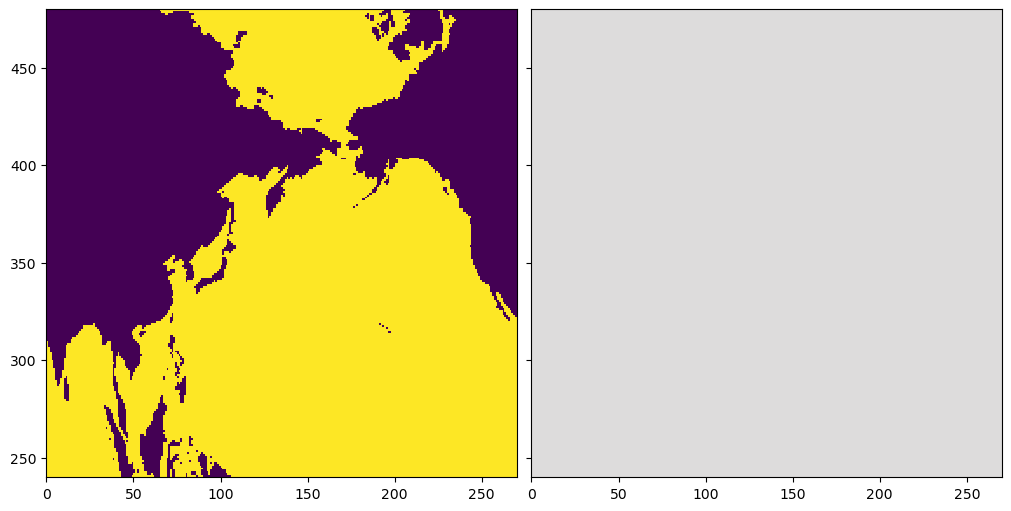

In [105]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(0,270)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

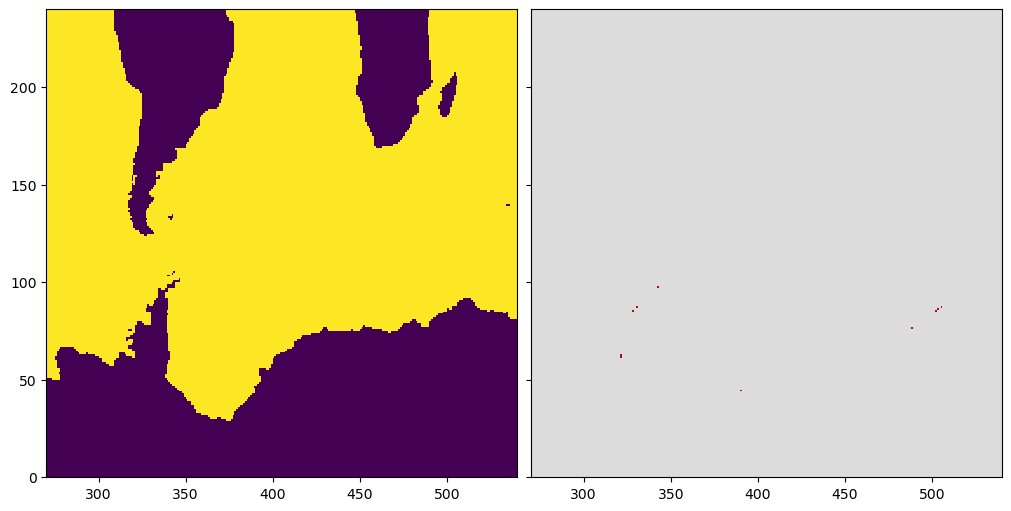

In [106]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(270,540)
ax[0].set_ylim(0,240)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

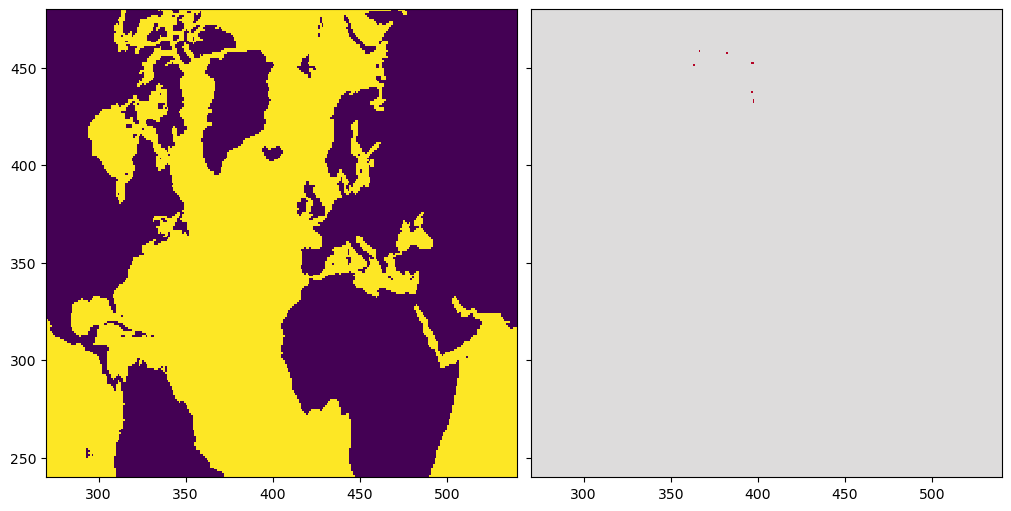

In [107]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(270,540)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

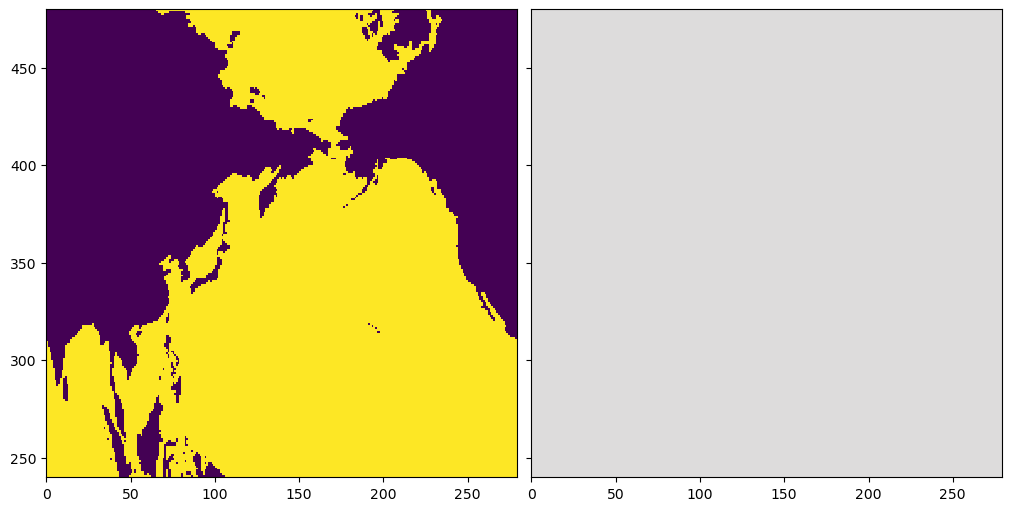

In [108]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_new['mask'],cmap='viridis',vmin=0,vmax=1)
ax[0].set_xlim(0,279)
ax[0].set_ylim(240,480)
ax[1].pcolormesh((df_old['mask'] - df_new['mask']),vmin=-1,vmax=1,cmap='coolwarm')

0.0


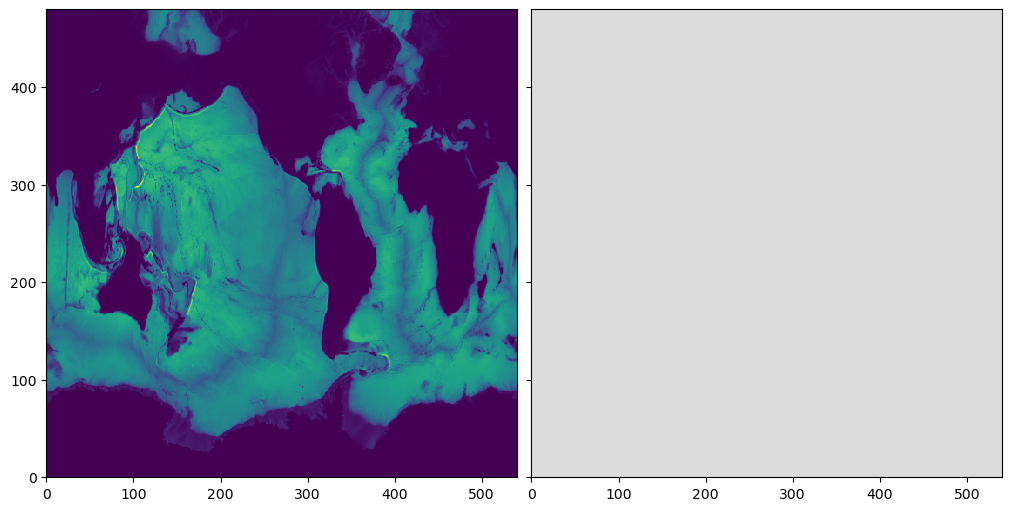

In [109]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_old['D_mean'],cmap='viridis')
ax[1].pcolormesh((df_old['D_mean'] - df_new['D_mean']),cmap='coolwarm',vmin=-1,vmax=1)

print(np.max(np.abs((df_old['D_mean'] - df_new['D_mean']).values)))

888.45874


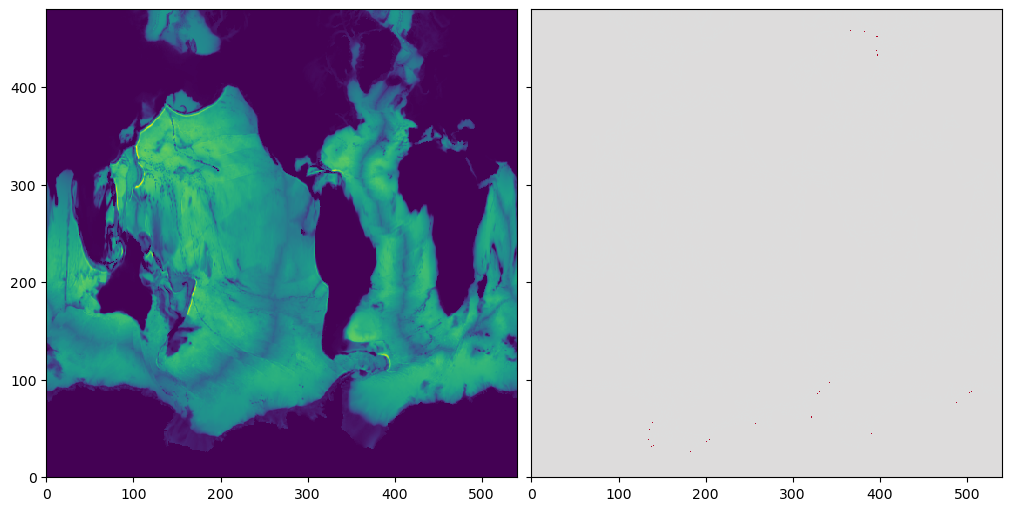

In [110]:
fig,ax=plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,5),constrained_layout=True)

ax[0].pcolormesh(df_old['D_interp'],cmap='viridis')
ax[1].pcolormesh((df_old['D_interp'] - df_new['D_interp']),cmap='coolwarm',vmin=-1,vmax=1)

print(np.max(np.abs((df_old['D_interp'] - df_new['D_interp']).values)))